# Klasteryzacja

## Konfiguracja

Użyjemy standardowych bibliotek oraz dodatkowo:
- Plotly - do wizualizacji
- UMAP - redukcja wymiarowości

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn


sklearn.set_config(transform_output="pandas")

## Analiza muzyki ze Spotify

Spotify w swoim API oferuje automatyczną [ekstrakcję cech z piosenek](https://developer.spotify.com/documentation/web-api/reference/get-audio-features), których można następnie użyć do wielu ciekawych analiz, jak np. [tutaj](https://rpubs.com/PeterDola/SpotifyTracks) lub [tutaj](https://rstudio-pubs-static.s3.amazonaws.com/604869_8399a2cf0e4a419da6272452c3d6a6d3.html). Datasetów jest wiele, z czego jednym z największych [jest dostępny tutaj na Kaggle](https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks?select=tracks.csv) i zawiera ponad 600 tysięcy piosenek.

Cechy zwracane przez API to m. in. akustyczność, taneczność, energia, głośność czy długość piosenki. Pełna lista cech jest dostępna [w dokumentacji](https://developer.spotify.com/documentation/web-api/reference/get-audio-features). Są to bardzo dobre cechy do uczenia maszynowego - niewielka wymiarowość i tylko numeryczne. Wadą jest pewna dość mocna korelacja w niektórych podgatunkach muzycznych, ale akurat to w przypadku klasteryzacji takich danych jest całkiem ok, i może prowadzić do sensownych wniosków.

Spotify definiuje i wykorzystuje ponad 125 gatunków muzycznych, które na dodatek są dość dyskusyjne i płynne. Przykładowo, według różnych klasyfikacji Powerwolf, Ensiferum i Alestorm mogą wylądować w tym samym worku, pomimo zdecydowanie różnej muzyki. Klasteryzacja pozwala tworzyć "płynne" tagi, klasyfikując muzykę w dużo bardziej zniuansowany sposób.

**Uwaga:** zgodnie z licencją API danych nie można używać do treningu modeli ML. Oczywiście tego typu licencje nie dotyczą użytku prywatnego ani zastosowań naukowych, co wynika z ogólnych przepisów. Należy jednak pamiętać, że takich modeli nie wolno w żaden sposób publikować ani wykorzystywać komercyjnie.

**Zadanie 1 (2.5 punktu)**

1. Ściągnij pliki `artists.csv` oraz `tracks.csv` z Kaggle'a.
2. Załaduj pliki `artists.parquet` i `tracks.parquet` do zmiennych `df_artists` i `df_tracks`.
3. Usuń wiersze z wartościami brakującymi z obu ramek danych.
4. Ponad 600 tysięcy piosenek to zdecydowanie za dużo, a na dodatek przeważająca większość z nich to drobni, mało znani artyści. Aby to zweryfikować, narysuj histogramy popularności artystów oraz piosenek. Użyj 100 kubełków (bins). Pamiętaj o tytułach wykresów.
5. Dokonaj filtrowania:
   - pozostaw artystów z popularnością >= 55
   - pozostaw piosenki z popularnością >= 55
   - usuń piosenki trwające powyżej 600000 ms (10 minut)
   - użyj funkcji `remove_weird_genres()`, żeby usunąć artystów z ekstremalnie rzadkich gatunków muzycznych
   - użyj funkcji `filter_english_only()`, aby pozostawić tylko anglojęzyczne tytuły
6. Użyj podanej funkcji `extract_artist_id()` na ramce z piosenkami, która dodaje kolumnę `main_artist_id`.
7. Połącz ramki w jedną, `df_songs`, z wszystkimi informacjami:
   - użyj kolumn `main_artist_id` (ramka z piosenkami) oraz `id` (ramka z artystami)
   - przyda się `pd.merge()`
   - Pandas automatycznie dodaje sufiksy do kolumn (argument `suffixes`), żeby rozróżnić kolumny po takiej operacji JOIN
   - domyślnie są to mało znaczące `_x` i `_y`, zmień je na `_track` i `_artist`
8. Usuń duplikaty wedle kolumn `name_track` oraz `name_artist`.
9. Mamy kolumny z danymi, które identyfikują piosenki: nazwa piosenki, artysta, gatunki muzyczne. Nie są one jednak użyteczne do samej klasteryzacji. Wyodrębnij je do osobnej ramki `df_songs_info`.
```
songs_info_cols = [
    "name_track",
    "name_artist",
    "genres"
]
```
10. Stwórz nową ramkę `df_songs_features`, pozostawiając tylko kolumny z cechami do klasteryzacji:
```
songs_features_cols = [
    "explicit",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]
```
11. Wypisz finalną liczbę piosenek (rozmiar zbioru).

**Uwaga:** jeżeli notebook będzie wykonywał się zbyt długo, to można ustawić wyższy próg popularności, żeby uzyskać mniejszy podzbiór najbardziej popularnych piosenek.

In [2]:
import ast
from fast_langdetect import detect as detect_language


def extract_artist_id(df_tracks: pd.DataFrame) -> pd.DataFrame:
    df_tracks["main_artist_id"] = df_tracks["id_artists"].apply(
        lambda x: ast.literal_eval(x)[0]
    )
    return df_tracks


def remove_weird_genres(df_songs: pd.DataFrame) -> pd.DataFrame:
    all_genres = []
    for song_genres in df_songs["genres"]:
        all_genres.extend(ast.literal_eval(song_genres))

    df_genres = pd.Series(all_genres).value_counts().reset_index()

    weird_genres = df_genres.loc[df_genres["count"] < 150, "index"]
    weird_genres = set(weird_genres.tolist())

    to_keep = []
    for song_genres in df_songs["genres"]:
        song_genres = set(ast.literal_eval(song_genres))
        not_all_weird = len(song_genres - weird_genres) > 0
        to_keep.append(not_all_weird)

    df_songs = df_songs[to_keep]
    return df_songs


def filter_english_only(df_songs: pd.DataFrame) -> pd.DataFrame:
    english = [
        detect_language(title[:100], low_memory=False)["lang"] == "en"
        for title in df_songs["name"]
    ]
    return df_songs[english]


In [3]:
# Ad 1, 2
df_tracks = pd.read_csv("data/tracks.csv")
df_artists = pd.read_csv("data/artists.csv")


print("Number of tracks:", len(df_tracks))
print("Number of artists:", len(df_artists))

Number of tracks: 586672
Number of artists: 1162095


In [4]:
# Ad 3
df_tracks = df_tracks[df_tracks.notna().any(axis=1)]
df_artists = df_artists[df_artists.notna().any(axis=1)]

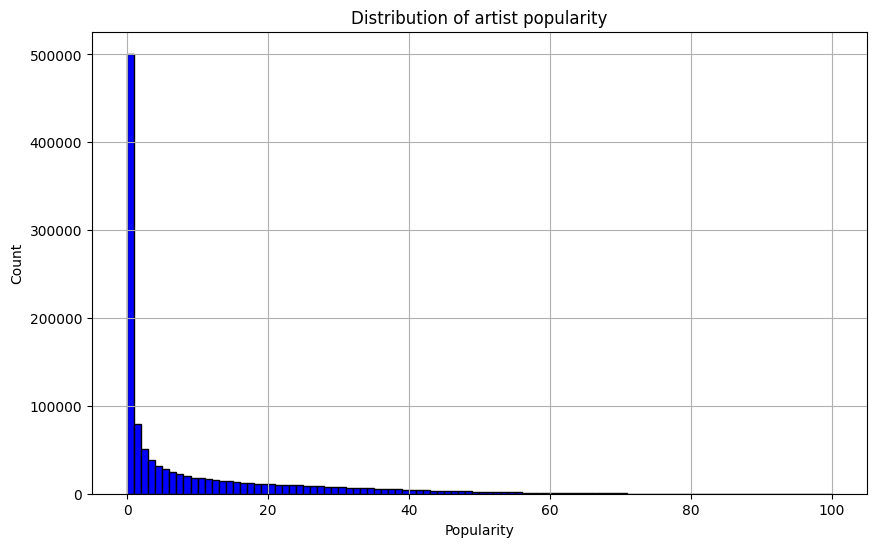

In [5]:
# Ad 4
df_artists.hist(
    column="popularity", bins=100, figsize=(10, 6), color="blue", edgecolor="black"
)
plt.title("Distribution of artist popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

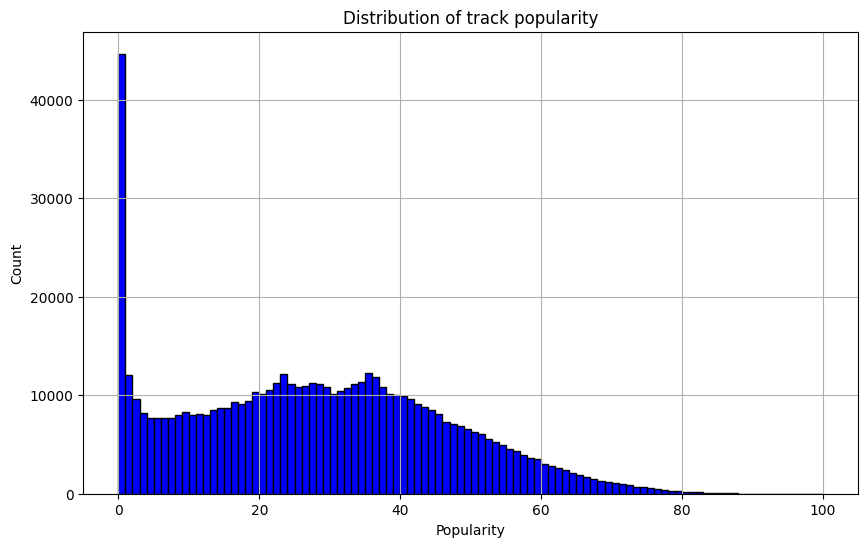

In [6]:
df_tracks.hist(
    column="popularity", bins=100, figsize=(10, 6), color="blue", edgecolor="black"
)
plt.title("Distribution of track popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

In [7]:
# Ad 5

# artists
popularity_threshold = 55

df_artists_filtered = df_artists[df_artists["popularity"] >= popularity_threshold]
df_artists_filtered = remove_weird_genres(df_artists_filtered)


# tracks
length_threshold = 600_000

df_tracks_filtered = df_tracks[
    (df_tracks["popularity"] >= popularity_threshold)
    & (df_tracks["duration_ms"] <= length_threshold)
]
df_tracks_filtered = filter_english_only(df_tracks_filtered)

In [8]:
# Ad 6

df_tracks_filtered = extract_artist_id(df_tracks)

In [9]:
# Ad 7

df_songs = pd.merge(
    df_tracks_filtered,
    df_artists_filtered,
    left_on="main_artist_id",
    right_on="id",
    suffixes=("_track", "_artist"),
)

In [10]:
df_songs.head()

,id_track,name_track,popularity_track,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,liveness,valence,tempo,time_signature,main_artist_id,id_artist,followers,genres,name_artist,popularity_artist
0,3eMrYc092k7SIJfWJ7oasR,Weather Bird,38,161933,0,"['Louis Armstrong', 'Earl Hines']","['19eLuQmk9aCobbVDHc6eek', '2mY5u4CceAPrpBnse1...",1923,0.831,0.262,...,0.204,0.901,104.606,4,19eLuQmk9aCobbVDHc6eek,19eLuQmk9aCobbVDHc6eek,2256652.0,"['adult standards', 'dixieland', 'harlem renai...",Louis Armstrong,74
1,7lRFR5GJCxK87ZbVMtQSeS,Ain't Misbehavin',28,192600,0,['Louis Armstrong'],['19eLuQmk9aCobbVDHc6eek'],1923,0.665,0.254,...,0.644,0.503,125.734,4,19eLuQmk9aCobbVDHc6eek,19eLuQmk9aCobbVDHc6eek,2256652.0,"['adult standards', 'dixieland', 'harlem renai...",Louis Armstrong,74
2,5WlMyDvyQedom0kQ3MCTow,Lazy River,14,182707,0,['Louis Armstrong'],['19eLuQmk9aCobbVDHc6eek'],1923,0.571,0.269,...,0.121,0.490,101.845,4,19eLuQmk9aCobbVDHc6eek,19eLuQmk9aCobbVDHc6eek,2256652.0,"['adult standards', 'dixieland', 'harlem renai...",Louis Armstrong,74
3,3U6L5KW48YOsksN9Qvlydl,I've Got The World On A String,11,195000,0,['Louis Armstrong'],['19eLuQmk9aCobbVDHc6eek'],1923,0.544,0.181,...,0.401,0.411,129.803,4,19eLuQmk9aCobbVDHc6eek,19eLuQmk9aCobbVDHc6eek,2256652.0,"['adult standards', 'dixieland', 'harlem renai...",Louis Armstrong,74
4,1v6v5llnekLbreJYIRfkKc,Chicago Breakdown,8,203307,0,['Louis Armstrong'],['19eLuQmk9aCobbVDHc6eek'],1923,0.604,0.325,...,0.195,0.629,168.506,4,19eLuQmk9aCobbVDHc6eek,19eLuQmk9aCobbVDHc6eek,2256652.0,"['adult standards', 'dixieland', 'harlem renai...",Louis Armstrong,74


In [11]:
# Ad 8

df_songs = df_songs.drop_duplicates(subset=["name_track", "name_artist"])

In [12]:
# Ad 9

songs_info_cols = ["name_track", "name_artist", "genres"]

df_songs_info = df_songs[songs_info_cols]
df_songs = df_songs.drop(columns=songs_info_cols)

In [13]:
# Ad 10

songs_features_cols = [
    "explicit",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

df_songs_features = df_songs[songs_features_cols]

In [14]:
# Ad 11

print(
    f"Number of songs: {len(df_songs_features)}, number of features: {len(df_songs_features.columns)}"
)

Number of songs: 110158, number of features: 9


Mamy teraz przygotowane dane, więc można brać się za klasteryzację. Nasz zbiór jest dość duży, nawet po dokonanym ostrym filtrowaniu, więc potrzebujemy skalowalnych algorytmów klasteryzacji. Klasteryzacja hierarchiczna zdecydowanie odpada, pozostają więc k-means, DBSCAN i HDBSCAN. Co prawda hiperparametry do DBSCAN ciężko jest dobrać, ale zobaczymy, jak można to zrobić.

Zanim przejdziemy do klasteryzacji, trzeba ustandardyzować nasze dane. Po tym trzeba przeprowadzić też globalną analizę naszego zbioru, jak na przykład rozkłady cech, albo zwizualizować go z pomocą redukcji wymiaru. Jest to ważne, bo przy późniejszej analizie klastrów musimy wiedzieć, czy klastry w ogóle różnią się od ogółu naszych danych.

**Zadanie 2 (1 punkt)**

1. Dokonaj standaryzacji cech, tworząc ramkę `X`.
2. Uzupełnij kod klasy `ClusteringVisualizer`, która przyjmuje dane, numery klastrów dla poszczególnych punktów (opcjonalne), i przedstawia wykresy PCA oraz UMAP:
   - zredukuj dane do 2 wymiarów
   - pamiętaj o `random_state=0`
   - [dokumentacja UMAP](https://umap-learn.readthedocs.io/en/latest/basic_usage.html)
   - przekaż `low_memory=False` dla UMAP
   - ze względu na specyfikę implementacji, wykorzystanie `.fit_transform()` będzie zauważalnie szybsze od osobnych `.fit()` i `.transform()`
   - skomentuj:
     - czy w przypadku PCA widać jakąś strukurę klastrów?
     - czy widać ją w przypadku UMAP?
     - czy redukcja nieliniowa dała lepsze, czy gorsze wyniki od liniowego PCA w wizualizacji?

Czemu klasa, a nie funkcja? UMAP, jak praktycznie wszystkie metody nieliniowej redukcji wymiaru, wykorzystuje graf najbliższych sąsiadów. Jeżeli obliczymy dane po redukcji raz, i zapiszemy jako atrybut, to później będziemy mogli uniknąć liczenia tego wielokrotnie. Zapisanie tych wyników zaoszczędzi nam wiele minut :)

In [15]:
from typing import Optional

from IPython.display import display
from sklearn.decomposition import PCA
from umap.umap_ import UMAP


class ClusteringVisualizer:
    def __init__(self, X: np.ndarray | pd.DataFrame):
        self.X = X

        # PCA
        self.pca = PCA(n_components=2, random_state=0)
        self.X_pca = self.pca.fit_transform(X)

        # UMAP
        self.umap = UMAP(n_components=2, random_state=0, low_memory=False)
        self.X_umap = self.umap.fit_transform(X)

    def visualize(self, labels: Optional[np.ndarray] = None):
        if labels is None:
            labels = np.ones(len(self.X))

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # axes[0] - PCA
        scatter_pca = axes[0].scatter(
            np.asarray(self.X_pca)[:, 0],
            np.asarray(self.X_pca)[:, 1],
            c=labels,
            s=1,
            cmap="inferno",
        )
        axes[0].set_title("PCA")
        axes[0].set_xlabel("PCA Component 1")
        axes[0].set_ylabel("PCA Component 2")
        if labels is not None:
            axes[0].legend(*scatter_pca.legend_elements(), title="Labels")

        # axes[1] - UMAP
        scatter_umap = axes[1].scatter(
            np.asarray(self.X_umap)[:, 0],
            np.asarray(self.X_umap)[:, 1],
            c=labels,
            s=1,
            cmap="inferno",
        )
        axes[1].set_title("UMAP")
        axes[1].set_xlabel("UMAP Component 1")
        axes[1].set_ylabel("UMAP Component 2")
        if labels is not None:
            axes[1].legend(*scatter_umap.legend_elements(), title="Labels")

        fig.suptitle("Clustering visualization")
        plt.show()


In [16]:
# Ad 1

from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df_songs_features)

/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


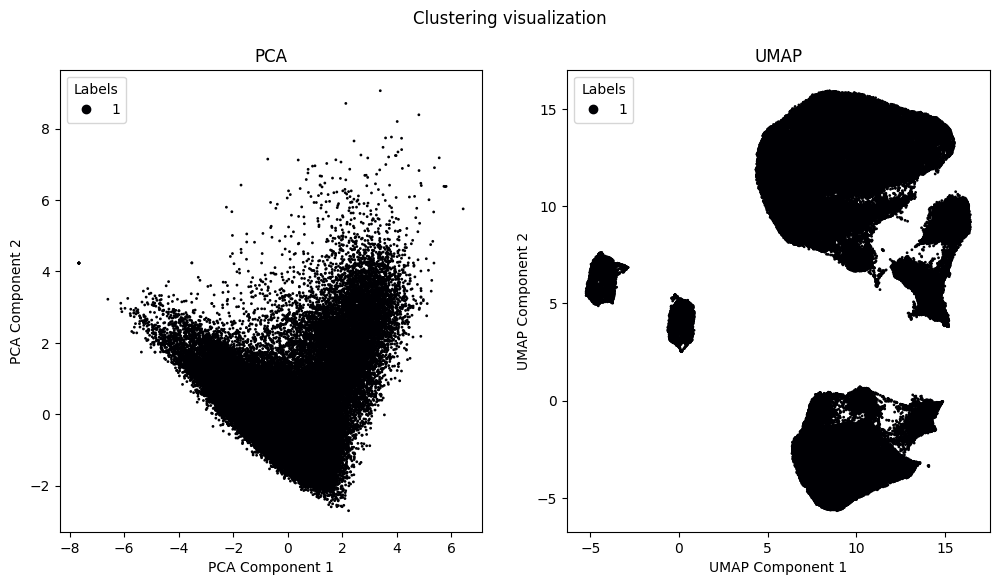

In [17]:
clustering_visualizer = ClusteringVisualizer(X)
clustering_visualizer.visualize()

// skomentuj tutaj

 - W przypadku UMAP mamy wyraźną struktkurę klastrów.
 - W przypadku PCA widać jakieś zróżnicowanie względem rozkładu (prawa górna część "serca" jest bardziej rzadka), ale de facto mamy tylko jedną dużą chmurę punktów, która jest bardzo rozciągnięta.

Zatem nieliniowa klasteryzacja dała zdecydowanie lepsze wyniki.

Teraz przeanalizujemy nasz zbiór. Posłużą nam do tego poniżej zdefiniowane klasy `KMeansAnalzyer`, `DBSCANAnalyzer` i `HDBSCANAnalyzer`. Metoda `.analyze_clustering()` dla każdego klastra:
1. Wypisuje liczbę klastrów, oraz informację o szumie (dla DBSCAN i HDBSCAN).
2. Wypisuje wartość metryki [Calinski-Harabasz index](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html), jeżeli liczba klastrów to co najmniej 2. Dla DBSCAN i HDBSCAN uwzględniamy tylko punkty z klastrów, ignorując szum.
2. Rysuje wykres klastrów po redukcji z PCA oraz UMAP.
3. Tworzy [wykres radowy (radar chart)](https://plotly.com/python/radar-chart/). Pozwala on wygodnie porównać wartości średnie dla poszczególnych cech.
4. Wypisuje piosenki i artystów reprezentujące klaster:
   - dla k-means jest to 10 punktów najbliższych do centroidu
   - dla DBSCAN wybieramy heurystycznie 10 punktów najbliższych do centroidu
   - dla HDBSCAN wybieramy punkty o najwyższym prawdopodobieństwie (nie używamy exemplars, bo jest to bardzo wolne [i mało wygodne](https://github.com/scikit-learn-contrib/hdbscan/issues/304))
5. Wypisuje 10 najczęstszych gatunków muzycznych w klastrze.

Dla DBSCAN i HDBSCAN, które same wykrywają liczbę klastrów i może być ich bardzo dużo, analizowane jest tylko:
- max 10 największych klastrów
- tylko te, które mają co najmniej 100 próbek

Na początek potraktujemy cały nasz zbiór jako jeden wielki klaster dla algorytmu k-means i popatrzymy, co tam się dzieje.

In [18]:
import itertools
from abc import ABC, abstractmethod
from collections import Counter

import plotly.graph_objects as go

from sklearn.cluster import DBSCAN, KMeans

# changed from sklearn.cluster import HDBSCAN as it does not support memory
from hdbscan import HDBSCAN

from sklearn.metrics import calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import minmax_scale


class ClusteringAnalyzer(ABC):
    def __init__(
        self, df_songs_info: pd.DataFrame, clustering_visualizer: ClusteringVisualizer
    ):
        self.df_songs_info = df_songs_info
        self.clustering_visualizer = clustering_visualizer

    @abstractmethod
    def analyze_clustering(self, X: pd.DataFrame, clustering) -> None:
        raise NotImplementedError()

    def _get_top_clusters_labels(self, labels: np.ndarray) -> np.ndarray:
        labels = labels[labels != -1]
        label_counts = pd.Series(labels).value_counts()
        label_counts = label_counts[label_counts >= 100]
        top_labels = label_counts.index[:10].values
        return top_labels

    def _create_radar_chart(self, X: pd.DataFrame, label: int) -> None:
        fig = go.Figure()
        vals = minmax_scale(X).mean()
        fig.add_trace(go.Scatterpolar(r=vals, theta=X.columns, fill="toself"))
        fig.update_layout(title_text=f"Cluster {label}", title_x=0.5)
        fig.update_polars(radialaxis=dict(range=[0, 1]))
        fig.show()

    def _get_central_songs(
        self, X: pd.DataFrame, cluster_songs_info: pd.DataFrame, prototype: np.ndarray
    ) -> None:
        n_neighbors = min(10, len(X))
        nn = NearestNeighbors(n_neighbors=n_neighbors, n_jobs=-1)
        nn.fit(X.values)
        _, nn_idxs = nn.kneighbors(prototype)
        nn_idxs = nn_idxs.ravel()
        nn_songs_info = cluster_songs_info.iloc[nn_idxs]
        nn_songs_info = nn_songs_info.drop(columns="genres")
        nn_songs_info.columns = ["Track", "Artist"]
        nn_songs_info = nn_songs_info.reset_index(drop=True)
        display(nn_songs_info)

    def _get_cluster_top_genres(
        self,
        cluster_songs_info: pd.DataFrame,
    ) -> None:
        genres = cluster_songs_info["genres"].values
        genres = [ast.literal_eval(x) for x in genres]
        genres = Counter(itertools.chain(*genres))
        top_genres = genres.most_common(10)
        top_genres = [name for name, count in top_genres]
        print("Top 10 genres in the cluster:", top_genres)


class KMeansAnalyzer(ClusteringAnalyzer):
    def analyze_clustering(self, X: pd.DataFrame, clustering: KMeans) -> None:
        labels = clustering.labels_
        centroids = clustering.cluster_centers_

        print(f"Number of clusters: {max(labels) + 1}")

        if labels.max() >= 2:
            ch_index = calinski_harabasz_score(X, labels)
            print(f"CH-index value: {ch_index:.2f}")

        self.clustering_visualizer.visualize(labels)

        for label in range(0, max(labels) + 1):
            X_cluster = X[labels == label]
            cluster_songs_info = df_songs_info[labels == label]
            centroid = centroids[label].reshape((1, -1))

            print(f"Cluster {label} size: {len(X_cluster)}")
            self._create_radar_chart(X_cluster, label)
            self._get_central_songs(X_cluster, cluster_songs_info, centroid)
            self._get_cluster_top_genres(cluster_songs_info)


class DBSCANAnalyzer(ClusteringAnalyzer):
    def analyze_clustering(self, X: pd.DataFrame, clustering: DBSCAN) -> None:
        labels = clustering.labels_

        noise_num = (labels == -1).sum()
        noise_perc = noise_num / len(X)

        print(f"Number of clusters: {max(labels) + 1}")
        print(f"Percentage of noise points: {100 * noise_perc:.2f}%")

        if labels.max() >= 2:
            X_non_noise = X[labels != -1]
            labels_non_noise = labels[labels != -1]
            ch_index = calinski_harabasz_score(
                X_non_noise,
                labels_non_noise,
            )
            print(f"CH-index value: {ch_index:.2f}")

        self.clustering_visualizer.visualize(labels)

        for label in self._get_top_clusters_labels(labels):
            X_cluster = X[labels == label]
            cluster_songs_info = df_songs_info[labels == label]
            centroid = self._get_cluster_centroid(X_cluster)

            print(f"Cluster {label} size: {len(X_cluster)}")
            self._create_radar_chart(X_cluster, label)
            self._get_central_songs(X_cluster, cluster_songs_info, centroid)
            self._get_cluster_top_genres(cluster_songs_info)

    def _get_cluster_centroid(self, X_cluster: pd.DataFrame) -> np.ndarray:
        centroid = np.mean(X_cluster.values, axis=0)
        return np.array(centroid).reshape((1, -1))


class HDBSCANAnalyzer(ClusteringAnalyzer):
    def analyze_clustering(self, X: pd.DataFrame, clustering: HDBSCAN) -> None:
        labels = clustering.labels_
        probas = clustering.probabilities_

        noise_num = (labels == -1).sum()
        noise_perc = noise_num / len(X)

        print(f"Number of clusters: {max(labels) + 1}")
        print(f"Percentage of noise points: {100 * noise_perc:.2f}%")

        if labels.max() >= 2:
            X_non_noise = X[labels != -1]
            labels_non_noise = labels[labels != -1]
            ch_index = calinski_harabasz_score(
                X_non_noise,
                labels_non_noise,
            )
            print(f"CH-index value: {ch_index:.2f}")

        self.clustering_visualizer.visualize(labels)

        for label in self._get_top_clusters_labels(labels):
            X_cluster = X[labels == label]
            cluster_songs_info = df_songs_info[labels == label]
            cluster_probas = probas[labels == label]

            print(f"Cluster {label} size: {len(X_cluster)}")
            self._create_radar_chart(X_cluster, label)
            self._get_most_probable_songs(X_cluster, cluster_songs_info, cluster_probas)
            self._get_cluster_top_genres(cluster_songs_info)

    def _get_most_probable_songs(
        self,
        X: pd.DataFrame,
        cluster_songs_info: pd.DataFrame,
        cluster_probas: np.ndarray,
    ) -> None:
        top_10_indexes = np.argpartition(cluster_probas, -10)[-10:]
        nn_songs_info = cluster_songs_info.iloc[top_10_indexes]
        nn_songs_info = nn_songs_info.drop(columns="genres")
        nn_songs_info.columns = ["Track", "Artist"]
        nn_songs_info = nn_songs_info.reset_index(drop=True)
        display(nn_songs_info)

Number of clusters: 1


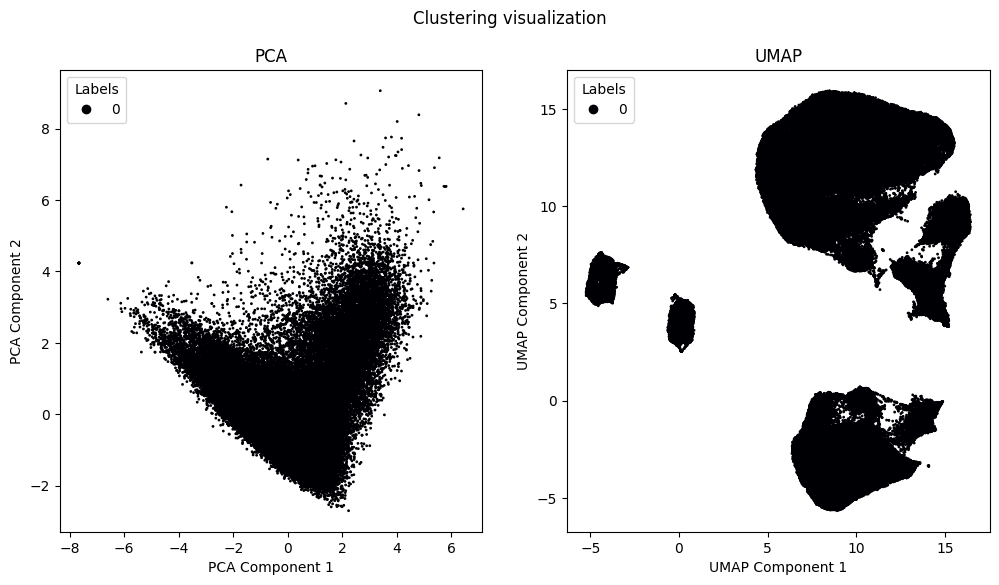

Cluster 0 size: 110158


,Track,Artist
0,Dating,A.R. Rahman
1,My Lady And Me - 2010 Digital Remaster,Little River Band
2,Don't Leave Me This Way (feat. Teddy Pendergra...,Harold Melvin & The Blue Notes
3,Vallan Vallende,Celia Cruz
4,Difícil,El Tri
5,Can You Dig It - Alternate Mix,The Monkees
6,Wait for Love,Luther Vandross
7,Walk On Water,Eddie Money
8,West Bound And Down,Jerry Reed
9,Pyar Karne Wale - Shaan / Soundtrack Version,Asha Bhosle


Top 10 genres in the cluster: ['rock', 'classic rock', 'adult standards', 'mellow gold', 'album rock', 'soft rock', 'folk rock', 'latin', 'soul', 'desi pop']


In [19]:
from sklearn.cluster import KMeans


clustering = KMeans(n_clusters=1, n_init="auto", random_state=0)
clustering.fit(X)

kmeans_analyzer = KMeansAnalyzer(df_songs_info, clustering_visualizer)
kmeans_analyzer.analyze_clustering(X, clustering)

Wygląda na to, że najpopularniejsze są pop i rock, a najbardziej "typowe" piosenki też należą do takiej grupy. Ogół piosenek ma dość dużą głośność, dużą dynamikę (wysokie time signature - "how many beats are in each bar") i są pozytywne (valence - "tracks with high valence sound more positive"). Zasadniczo jest to zgodne z intuicją. Ciekawe jednak, co będzie, jak wybierzemy więcej klastrów.

**Zadanie 3 (1.5 punktu)**

1. Wytrenuj k-means dla 3 klastrów.
2. Zwizualizuj wyniki za pomocą PCA i UMAP. Jako kolor punktów (np. parametr `c` w `plt.scatter()`) przekaż numery klastrów dla punktów.
3. Dokonaj opisu i analizy wynikowych klastrów, na przykład:
   - czy reprezentują jakieś konkretne grupy muzyczne?
   - na ile "konkretne", sensowne są klastry?
   - czy jest widoczna separacja klastrów, czy różnią się od siebie?
4. Dokonaj tuningu liczby klastrów:
   - sprawdź wartości z zakresu [5, 20] - w końcu wiemy, że gatunków jest sporo, i klastrów powinno też być więcej
   - dla każdej wartości sprawdź wartość metryki [Calinski-Harabasz index](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html)
   - przedstaw wykres liniowy (line plot) wartości metryki
   - wybierz model o najwyższej wartości metryki
   - zwizualizuj wyniki z pomocą PCA i UMAP
   - dokonaj interpretacji jego klastrów
   - skomentuj:
     - czy klastry są faktycznie lepiej interpretowalne po tuningu?
     - czy wysokość CH-index faktycznie odpowiada jakości klasteryzacji?


Number of clusters: 3
CH-index value: 19567.64


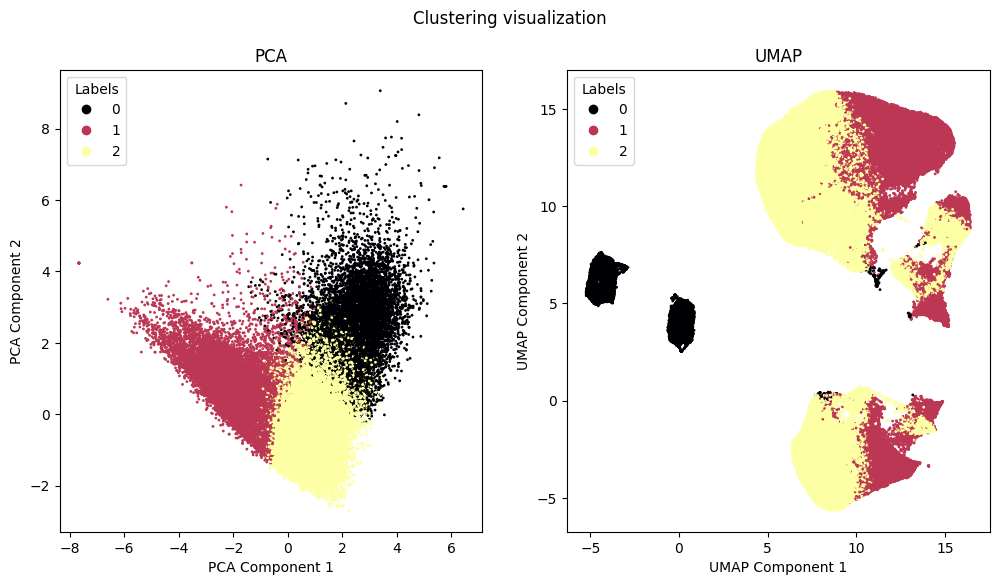

Cluster 0 size: 8777


,Track,Artist
0,Dándole,Arte Elegante
1,Putain d'époque,Lujipeka
2,okay,LANY
3,Ahora Dice Que Me Ama,Bandaga
4,Luxury,Azealia Banks
5,Me Llamas,Arcangel
6,Djomb - Bien ou quoi,Bosh
7,MEVTR,Damso
8,Vaillante,YL
9,Lost,Frank Ocean


Top 10 genres in the cluster: ['rap', 'hip hop', 'pop rap', 'gangster rap', 'french hip hop', 'trap', 'southern hip hop', 'pop', 'pop urbaine', 'hardcore hip hop']
Cluster 1 size: 35386


,Track,Artist
0,Vas a Ver,José José
1,Don't Go Near The Water - Remastered 2009,The Beach Boys
2,Another Try,America
3,I Know It's True,James Brown & The Famous Flames
4,I Wish You Love,Frank Sinatra
5,Helpless Dancer,The Who
6,Punchiri Thanjum,Shankar Mahadevan
7,Shades of Gray - 2007 Remaster,The Monkees
8,Here Comes the Night,Ben E. King
9,[Love Is] The Tender Trap,Frank Sinatra


Top 10 genres in the cluster: ['adult standards', 'vocal jazz', 'mellow gold', 'rock', 'lounge', 'classic rock', 'soft rock', 'soul', 'folk rock', 'desi pop']
Cluster 2 size: 65995


,Track,Artist
0,Fake ID,Riton
1,Gloria (feat. Van Morrison) - Mono Version,Them
2,Primitive Cool,Mick Jagger
3,Du bist mein erster Gedanke,Julio Iglesias
4,KRIMINELL,Kianush
5,Danger Ahead,Electric Light Orchestra
6,Love's No Friend,Rainbow
7,Pelo Suelto,Gloria Trevi
8,Sé Morir,Andrés Cepeda
9,Tainu Leke,Sonu Nigam


Top 10 genres in the cluster: ['rock', 'classic rock', 'album rock', 'mellow gold', 'soft rock', 'latin', 'hard rock', 'folk rock', 'dance pop', 'art rock']


In [20]:
means_3_clustring = KMeans(n_clusters=3, n_init="auto", random_state=0)
means_3_clustring.fit(X)

kmeans_analyzer.analyze_clustering(X, means_3_clustring)

// skomentuj tutaj

O ile w przypadku `Cluster 0` i `Cluster 2` gatunki muzyczne są raczej spójne, tak `Cluster 1` ma mieszankę róźnych niezwiązanych gatunków. Dla `Cluster 0` mamy gatunki wokół rapu, a dla `Cluster 2` mamy w wiekszości rodzaje rocka. Problemem też jest to, że dwa małe klastry w obrębie `Cluster 0` zostały potraktowane jako jeden, co wynika z 3-means - zbyt małej liczby klastrów.

In [21]:
N_CLUSTERS_SUITE = np.arange(5, 21)

print(f"Tuning KMeans with suite: {N_CLUSTERS_SUITE.tolist()}")

Tuning KMeans with suite: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [22]:
callinski_harabasz_scores = np.zeros(len(N_CLUSTERS_SUITE))

best_clustering: KMeans
best_ch_score = -np.inf
best_ch_index = -1
best_k = -1

for i, n_clusters in enumerate(N_CLUSTERS_SUITE):
    clustering = KMeans(n_clusters=n_clusters, n_init="auto", random_state=0)
    clustering.fit(X)

    current_ch_score = calinski_harabasz_score(X, clustering.labels_)

    callinski_harabasz_scores[i] = current_ch_score

    if current_ch_score > best_ch_score:
        best_ch_score = current_ch_score
        best_clustering = clustering
        best_ch_index = i
        best_k = n_clusters


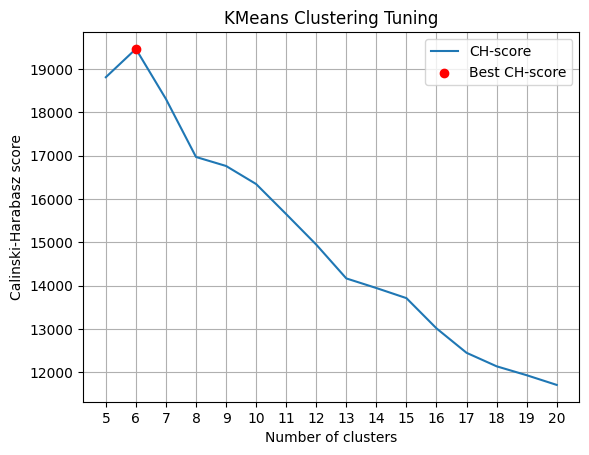

In [23]:
plt.plot(N_CLUSTERS_SUITE, callinski_harabasz_scores, label="CH-score")
plt.scatter(
    best_k,
    callinski_harabasz_scores[best_ch_index],
    color="red",
    zorder=5,
    label="Best CH-score",
)
plt.xlabel("Number of clusters")
plt.ylabel("Calinski-Harabasz score")
plt.title("KMeans Clustering Tuning")
plt.xticks(N_CLUSTERS_SUITE)
plt.grid()
plt.legend()
plt.show()

Number of clusters: 6
CH-index value: 19464.32


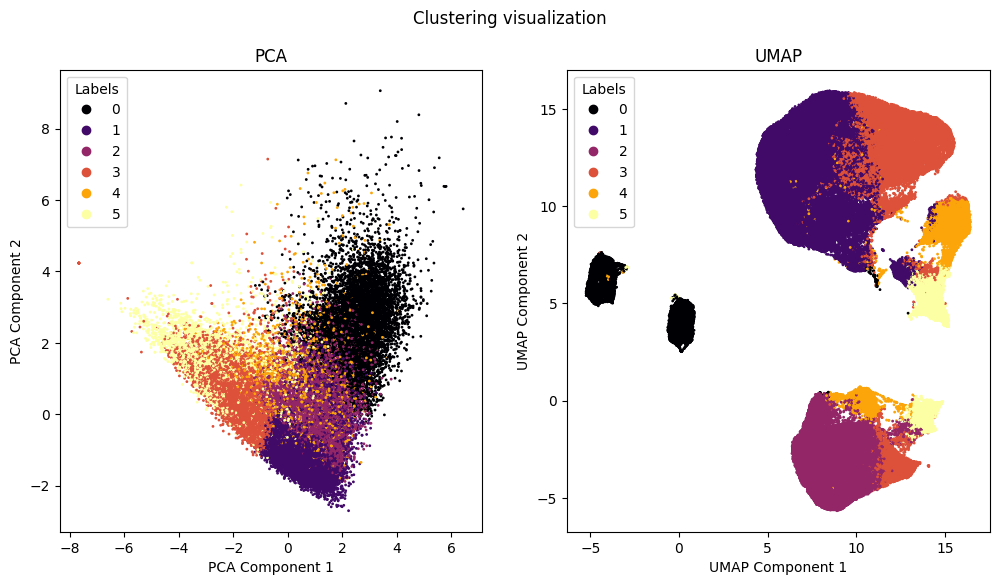

Cluster 0 size: 8490


,Track,Artist
0,Putain d'époque,Lujipeka
1,Dándole,Arte Elegante
2,okay,LANY
3,Ahora Dice Que Me Ama,Bandaga
4,Luxury,Azealia Banks
5,Soleil,Roméo Elvis
6,Me Llamas,Arcangel
7,MEVTR,Damso
8,Augenblick (feat. Summer Cem),KC Rebell
9,Djomb - Bien ou quoi,Bosh


Top 10 genres in the cluster: ['rap', 'hip hop', 'pop rap', 'gangster rap', 'trap', 'french hip hop', 'southern hip hop', 'pop', 'pop urbaine', 'hardcore hip hop']
Cluster 1 size: 40547


,Track,Artist
0,Primitive Cool,Mick Jagger
1,Sachi Ye Kahani Hai,Jatin-Lalit
2,Fortunate Son,Creedence Clearwater Revival
3,Gloria (feat. Van Morrison) - Mono Version,Them
4,Sé Morir,Andrés Cepeda
5,Agualluvia,Vicente Garcia
6,Our Day Will Come,Frankie Valli
7,Los Idiotas,Calle 13
8,Ik Junoon (Paint It Red),Vishal Dadlani
9,Back in N.Y.C. - New Stereo Mix,Genesis


Top 10 genres in the cluster: ['rock', 'classic rock', 'mellow gold', 'album rock', 'soft rock', 'latin', 'folk rock', 'hard rock', 'regional mexican', 'latin pop']
Cluster 2 size: 22228


...

Top 10 genres in the cluster: ['adult standards', 'mellow gold', 'vocal jazz', 'lounge', 'classic rock', 'rock', 'folk rock', 'soft rock', 'soul', 'brill building pop']
Cluster 4 size: 7803


,Track,Artist
0,Amoreena - Live Radio Broadcast,Elton John
1,"Emotions - Live at MTV Unplugged, Kaufman Asto...",Mariah Carey
2,The Night They Drove Old Dixie Down - Live at ...,Bob Dylan
3,"Song Sung Blue - Live At The Greek Theatre, Lo...",Neil Diamond
4,"I Shall Be Released - Live at LA Forum, Inglew...",Bob Dylan
5,Bill Bailey - Live,Sam Cooke
6,Come On In My Kitchen - Live,Steve Miller Band
7,I Saw Mommy Kissing Santa Claus,The Jackson 5
8,Kehna Ghalat Ghalat,Nusrat Fateh Ali Khan
9,Sweet Sixteen,B.B. King


Top 10 genres in the cluster: ['rock', 'classic rock', 'album rock', 'mellow gold', 'soft rock', 'adult standards', 'folk rock', 'rock en espanol', 'hard rock', 'art rock']
Cluster 5 size: 7415


,Track,Artist
0,Halo of Flies,Alice Cooper
1,The Morning: Another Morning - Remastered 2017,The Moody Blues
2,Blessed Relief,Frank Zappa
3,Bourée,Jethro Tull
4,About Today,The National
5,Jim Cain,Bill Callahan
6,Yours Is My Heart Alone,Ray Conniff
7,Loving You Is on My Mind,The Meters
8,"The James Bond Theme (From ""Dr. No"")",John Barry
9,Little Wing,Stevie Ray Vaughan


Top 10 genres in the cluster: ['rock', 'adult standards', 'classic rock', 'album rock', 'art rock', 'vocal jazz', 'lounge', 'jazz', 'desi pop', 'filmi']


In [24]:
kmeans_analyzer.analyze_clustering(X, best_clustering)

// komentarz do tuningu

Nie ma wielkiej poprawy, nadal dwie małe grupy w obrębie `Cluster 0` są traktowane jako jeden klaster. `Cluster 1` i `Cluster 2` mają takie same `radar-chart`, a ich gatunki muzyczne są bardzo podobne. Inne klastry, jeżeli chodzi o gatunki muzyczne, są różnorodne, ale też wyłoniły się inne gatunki niż przeważający wcześniej rock.

Problem z k-means jest taki, że wykrywa tylko klastry sferyczne. W przypadku zbiorów, w których klastry mogą być mocno wymieszane, będzie to szczególnym problemem. Tak może być tutaj - w końcu mamy co najmniej kilka podgatunków rocka i popu, które są zbliżone do siebie. Mamy też dość egzotyczne podgatunki takie jak "art rock" czy "rock en espanol", które być może są nieliczne i stanowią de facto szum.

Do takich sytuacji doskonale nadaje się DBSCAN. Ma co prawda większą złożoność, ale dla danych tego rozmiaru jest to jeszcze akceptowalne. Sprawdźmy, jak działa dla domyślnych hiperparametrów - epsilon 0.5 i min_samples 5.

Number of clusters: 343
Percentage of noise points: 31.08%
CH-index value: 114.35


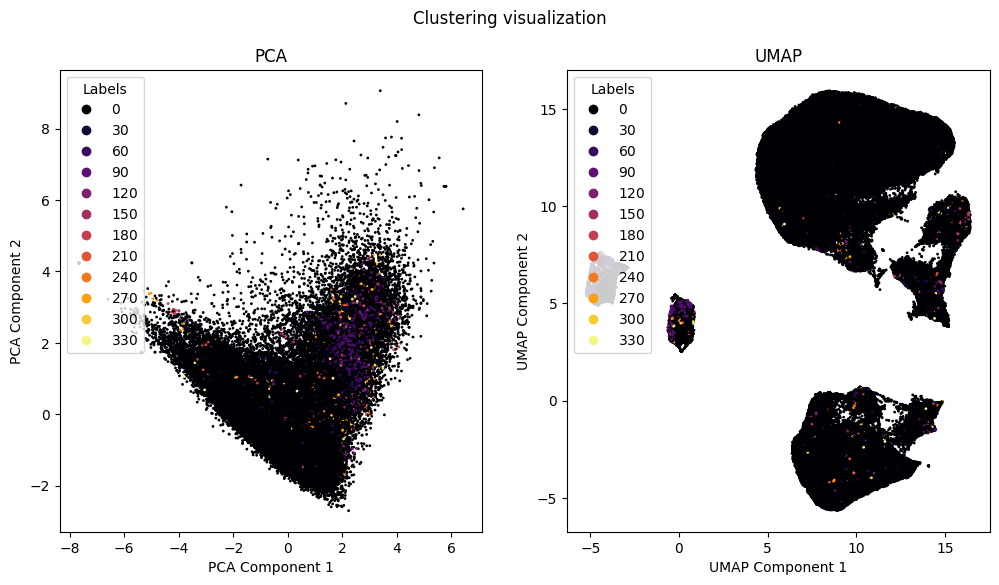

Cluster 0 size: 52556


,Track,Artist
0,Daniel Prayed,Patty Loveless
1,Lightning Rose,Jefferson Starship
2,Difícil,El Tri
3,Santa Monica,Savage Garden
4,Walk On Water,Eddie Money
5,The Worst Is Yet To Come - Remastered,Merle Haggard
6,Cup Of Tea,Kacey Musgraves
7,Lord Have Mercy on the Working Man,Travis Tritt
8,"Sigueme, Veras Felicidad",Los Iracundos
9,Wedding Bell Blues - Digitally Remastered: 1997,The 5th Dimension


Top 10 genres in the cluster: ['rock', 'classic rock', 'adult standards', 'mellow gold', 'soft rock', 'folk rock', 'album rock', 'latin', 'latin pop', 'country rock']
Cluster 1 size: 18526


,Track,Artist
0,Minchagi Neenu,Sonu Nigam
1,Hay algo en ella,Dyango
2,Break Away,The Beach Boys
3,The Wild Boys,Duran Duran
4,American Pie,Madonna
5,Poncho Konos,T3R Elemento
6,It Doesn't Matter,Stephen Stills
7,Toes Across The Floor,Blind Melon
8,Ya no somos amantes,Daniela Romo
9,Private Dancer - Single Edit,Tina Turner


Top 10 genres in the cluster: ['rock', 'classic rock', 'adult standards', 'latin', 'mellow gold', 'soft rock', 'album rock', 'desi pop', 'dance pop', 'filmi']
Cluster 61 size: 1016


...

Top 10 genres in the cluster: ['rap', 'pop rap', 'pop', 'french hip hop', 'pop urbaine', 'hip hop', 'dance pop', 'trap', 'rap francais', 'trap latino']
Cluster 3 size: 260


,Track,Artist
0,You're Getting To Be A Habit With Me,Oscar Peterson
1,On A Clear Day (You Can See Forever),Bill Evans
2,Do Nothin' Till You Hear From Me,Oscar Peterson
3,I've Got A Crush On You,Oscar Peterson
4,Things Ain't What They Used To Be,Oscar Peterson
5,Ankhon Mein Chitchor Samaye,Lata Mangeshkar
6,Someone To Watch Over Me,Ray Conniff
7,I Get A Kick Out Of You,Oscar Peterson
8,I Hear A Rhapsody,Ray Conniff
9,Wild Theme,Mark Knopfler


Top 10 genres in the cluster: ['adult standards', 'vocal jazz', 'cool jazz', 'jazz', 'jazz piano', 'lounge', 'bebop', 'stride', 'desi pop', 'filmi']
Cluster 83 size: 201


,Track,Artist
0,Sans ratures,Booba
1,Outta Control - Remix,50 Cent
2,Blood In Blood Out,Jedi Mind Tricks
3,Ryder Music,50 Cent
4,Killem With Kindness,Dizzy Wright
5,Ms. Jackson,Outkast
6,Suena Cabrrr (feat. Kendo Kaponi & Dy),Los De La Nazza
7,Mic Check,Rage Against The Machine
8,Jusqu'ici tout va bien,Booba
9,Toss It Up,Makaveli


Top 10 genres in the cluster: ['hip hop', 'rap', 'gangster rap', 'pop rap', 'hardcore hip hop', 'east coast hip hop', 'southern hip hop', 'west coast rap', 'g funk', 'conscious hip hop']


In [25]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN(n_jobs=-1)
clustering.fit(X)

dbscan_analyzer = DBSCANAnalyzer(df_songs_info, clustering_visualizer)
dbscan_analyzer.analyze_clustering(X, clustering)

Mamy niesamowicie dużo klastrów oraz szumu - niedobrze! Oznacza to, że zbyt ciężko jest "dotrzeć" do kolejnych punktów, żeby stworzyć klastry. Mogą być tego dwie przyczyny:
- zbyt mały promień epsilon
- zbyt duże min_samples

Biorąc pod uwagę, że minimalna liczba próbek to zaledwie 5, to to drugie nie występuje. Musimy zatem zwiększyć promień. Ale jak, skoro nie znamy jednostek?

Dobór hiperparametrów w DBSCAN dobrze opisuje [ten post](http://www.sefidian.com/2022/12/18/how-to-determine-epsilon-and-minpts-parameters-of-dbscan-clustering/), który zgadza się zresztą z "Data Clustering" Charu C. Aggarwala.

Wartość min_samples można przyjąć z grubsza (rule-of-thumb) jako liczbę wymiarów razy 2. Bierze to poprawkę na rzadkość przestrzeni, i generalnie jest dobrą wartością wyjściową. Jeżeli mamy dużo szumu, to można próbować więcej.

Przy stałym min_samples heurystyka do wyboru epsilon wygląda następująco. Obliczamy rozkład odległości do k najbliższych sąsiadów, przyjmując k = min_samples, a następnie przedstawiamy to na wykresie. Typowo będzie miał kształt z grubsza zbliżony do litery L (lub odwróconego L), i dobra wartość epsilon jest na punkcie przegięcia tego wykresu, tzw. elbow / knee.

**Zadanie 4 (1.5 punktu)**

Stwórz wykres odległości do najbliższych sąsiadów, przyjmując liczbę najbliższych sąsiadów równą 2 razy liczba cech. Może się przydać [ten tutorial](https://medium.com/@tarammullin/dbscan-parameter-estimation-ff8330e3a3bd).

Odczytaj z wykresu wartość punktu przegięcia. Czy jest to łatwe? Czy jesteś w stanie ją wyznaczyć dokładnie?

In [26]:
X_feature_count = X.shape[1]

min_samples = X_feature_count * 2

In [27]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=min_samples, n_jobs=-1)

In [28]:
nn.fit(X)

NearestNeighbors(n_jobs=-1, n_neighbors=18)

In [29]:
distances, _ = nn.kneighbors(X)
distances = np.sort(distances, axis=0)[:, -1]

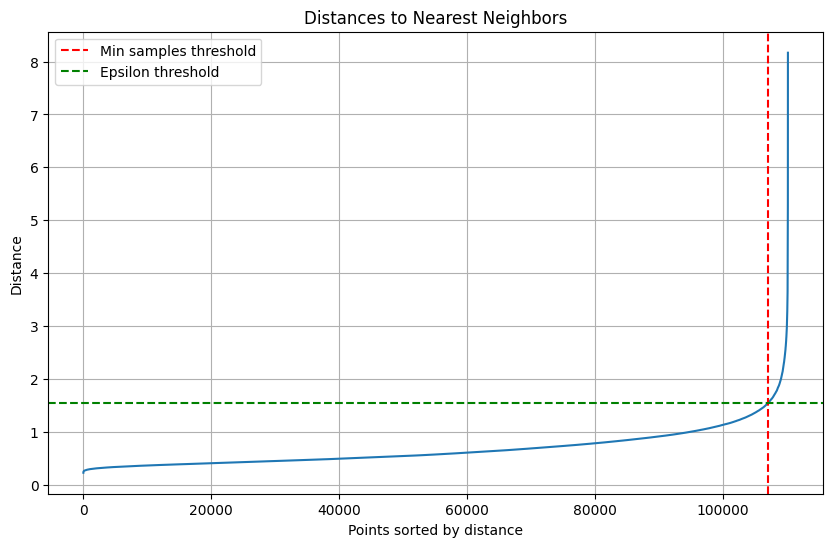

In [30]:
guessed_x = 107_000

plt.figure(figsize=(10, 6))
plt.plot(distances)
# estimating the inflection point
plt.title("Distances to Nearest Neighbors")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance")
plt.grid()

plt.axvline(x=guessed_x, color="red", linestyle="--", label="Min samples threshold")

epsilon = distances[guessed_x]

plt.axhline(
    y=epsilon,
    color="g",
    linestyle="--",
    label="Epsilon threshold",
)

plt.legend()
plt.show()

In [31]:
print(f"Guessed epsilon: {epsilon}")

Guessed epsilon: 1.5452950453603354


// skomentuj tutaj

Nie da się wyznaczyć tej wartości dokładnie, można estymować na oko.

Taka heurystyczna metoda jest wykorzystywana w wielu przypadkach doboru hiperparametrów w klasteryzacji. Zasadnicza idea jest taka, że punkt przegięcia odpowiada momentowi, gdzie dane zaczynają wyraźnie rozróżniać się od siebie i tworzyć wyraźne grupy. Jest to proste i szybkie, ale jest dość nieprecyzyjne w porównaniu do innych metod (jeżeli w ogóle istnieją dla danego zadania!). Jeżeli chcemy zrobić walidację skrośną, korzystając z jakiejś metryki, to taki wykres daje nam sensowny punkt wyjścia do zakresu hiperparametru.

Warto też pamiętać, że klasteryzacja to proces z natury interaktywny. Takie wykresy są ważne, bo zwiększają naszą intuicję, ale np. dokładne dobranie wartości jest typowo robione ręcznie.

**Zadanie 5 (1.5 punktu)**

Wytrenuj DBSCAN z promieniem epsilon wyznaczonym z wykresu i min_samples równym 2 razy liczbie cech. W razie potrzeby zmniejsz lub zwiększ epsilon, aby uzyskać wyniki, które wydają się sensowne (liczba klastrów, procent szumu, CH-index).

Dokonaj analizy wyjściowych klastrów. Czy finalna ich liczba oraz procent szumu są sensowne? Czy klastry są lepiej widoczne, lub lepiej interpretowalne, niż w przypadku k-means?

Number of clusters: 5
Percentage of noise points: 1.13%
CH-index value: 9404.07


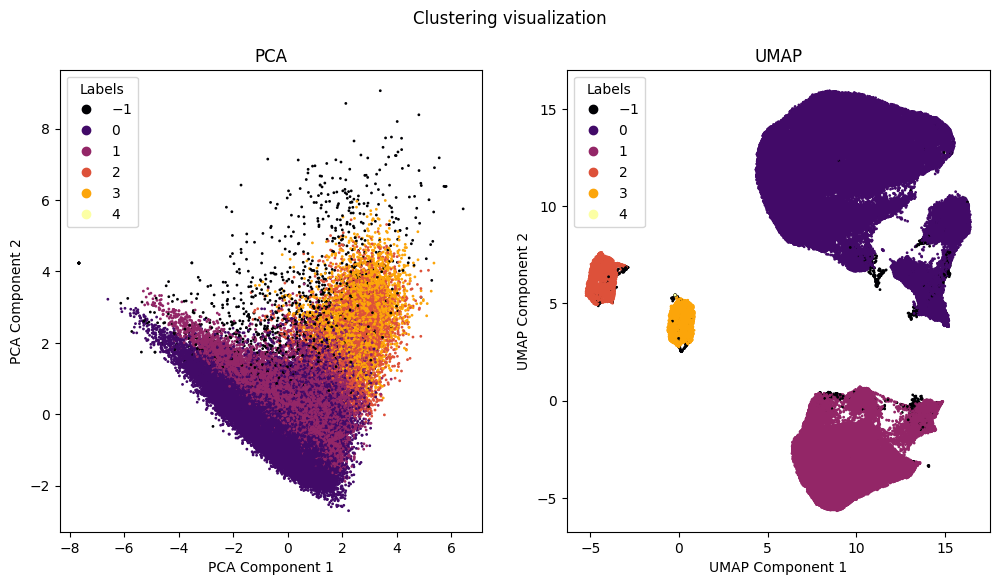

Cluster 0 size: 70670


,Track,Artist
0,My Lady And Me - 2010 Digital Remaster,Little River Band
1,Walk On Water,Eddie Money
2,Vallan Vallende,Celia Cruz
3,West Bound And Down,Jerry Reed
4,You Ain't Goin' Nowhere,Bob Dylan
5,Hazel,Bob Dylan
6,Can't Take My Eyes Off You,Engelbert Humperdinck
7,Difícil,El Tri
8,Dating,A.R. Rahman
9,You're so Different Tonight,Smokie


Top 10 genres in the cluster: ['rock', 'classic rock', 'adult standards', 'mellow gold', 'soft rock', 'album rock', 'folk rock', 'latin', 'country rock', 'soul']
Cluster 1 size: 30119


,Track,Artist
0,Door To My Heart,Buddy Holly
1,Electric Youth,Debbie Gibson
2,Minchagi Neenu,Sonu Nigam
3,Hide Your Heart,KISS
4,Another Man's Woman,Supertramp
5,Ya no somos amantes,Daniela Romo
6,Poncho Konos,T3R Elemento
7,Besame Mucho,Luis Miguel
8,Yeh Dhuan Dhuan,Roop Kumar Rathod
9,Young Guns (Go for It!),Wham!


Top 10 genres in the cluster: ['rock', 'classic rock', 'adult standards', 'album rock', 'desi pop', 'mellow gold', 'soft rock', 'filmi', 'latin', 'sufi']
Cluster 2 size: 4366


,Track,Artist
0,Putain d'époque,Lujipeka
1,Luxury,Azealia Banks
2,Broken Clocks,SZA
3,okay,LANY
4,Dándole,Arte Elegante
5,Worst Behavior,Drake
6,just like magic,Ariana Grande
7,Augenblick (feat. Summer Cem),KC Rebell
8,Anaconda,Nicki Minaj
9,63,Kaaris


Top 10 genres in the cluster: ['rap', 'hip hop', 'pop rap', 'gangster rap', 'southern hip hop', 'trap', 'pop', 'hardcore hip hop', 'dance pop', 'east coast hip hop']
Cluster 3 size: 3747


,Track,Artist
0,Soleil,Roméo Elvis
1,Ahora Dice Que Me Ama,Bandaga
2,7 sur 7,Koba LaD
3,Addiction,Kanye West
4,STFU,mansionz
5,Cardio,Dosseh
6,Perdoname,Mora
7,Dangerous (feat. YG),The Neighbourhood
8,LOW LIFE,Ufo361
9,Je vous déteste tous,Lorenzo


Top 10 genres in the cluster: ['rap', 'hip hop', 'pop rap', 'gangster rap', 'french hip hop', 'pop urbaine', 'trap', 'pop', 'southern hip hop', 'rap francais']


In [32]:
clustering = DBSCAN(min_samples=min_samples, eps=epsilon, n_jobs=-1)
clustering.fit(X)

dbscan_analyzer.analyze_clustering(X, clustering)

// skomentuj tutaj

Szumu jest znacznie mniej, a klastry są sensowne i spójne. W końcu dwa "optyczne" klastry czyli `Cluster 2` i `Cluster 3` są traktowane jako dwa oddzielne klastry, a nie jeden, choć mają zbliżone gatunki. W przypadku innych klastrów też widać, że są bardziej spójne. Możnaby też bardziej starać się podzielić `Cluster 0`, który ma też widoczny podklaster, choć mniej oczywisty niż w `Cluster 2` i `Cluster 3`.

DBSCAN ma dwie zasadnicze wady: trudny dobór hiperparametrów oraz podatność na szum. W szczególności to drugie widać, jeżeli w naszym zbiorze ciągle znajduje on dużo szumu - to oznaka, że mamy zmienną gęstość w danych i przydałoby się coś adaptacyjnego, jak OPTICS albo HDBSCAN. OPTICS jest bardziej zoptymalizowany pod pamięć niż szybkość w scikit-learn, plus ma raczej nieintuicyjne hiperparametry (może nawet bardziej, niż DBSCAN), więc wykorzystamy tutaj HDBSCAN.

Jego głównym hiperparametrem jest `min_cluster_size`, czyli po prostu minimalna liczba punktów, aby stworzyć klaster. Dodatkowo `min_samples` ma takie samo znaczenie, jak w DBSCAN, czyli jest to minimalna liczba punktów, aby utworzyć punkt typu CORE. Domyślnie są one równe, ale oczywiście można ustawić `min_samples` (sporo) mniejsze od `min_cluster_size`, i dostrajać oba.

/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



Number of clusters: 129
Percentage of noise points: 29.13%
CH-index value: 395.81


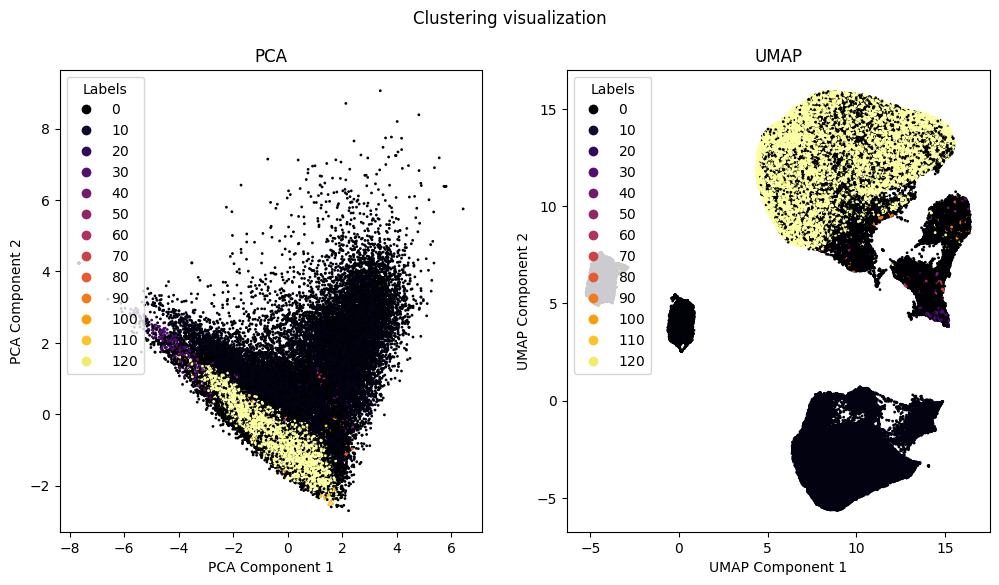

Cluster 128 size: 38103


,Track,Artist
0,Trust Fund Baby,Why Don't We
1,Need To Feel Loved (FYHYM2019),Cosmic Gate
2,See The End (FYHYM2019),Above & Beyond
3,Missing You,The Vamps
4,7UP,Boy In Space
5,Freaks,Jordan Clarke
6,Lotus Inn,Why Don't We
7,Meet Again,KIMSEJEONG
8,blind,ROLE MODEL
9,When It's Sleepy Time Down South,Louis Armstrong


Top 10 genres in the cluster: ['rock', 'adult standards', 'classic rock', 'mellow gold', 'soft rock', 'folk rock', 'album rock', 'latin', 'latin pop', 'brill building pop']
Cluster 3 size: 30374


,Track,Artist
0,I Cried for You (with Teddy Wilson & His Orche...,Billie Holiday
1,With Thee I Swing (with Teddy Wilson & His Orc...,Billie Holiday
2,Please Keep Me In Your Dreams,Billie Holiday
3,How Could You? (with Teddy Wilson & His Orches...,Billie Holiday
4,Come With Me (FYHYM2019),Cosmic Gate
5,Anjunafamily (FYHYM2019),Above & Beyond
6,8K (FYHYM2019),Giuseppe Ottaviani
7,Gone,Blake Rose
8,What They'll Say About Us,FINNEAS
9,Lazy River,Louis Armstrong


Top 10 genres in the cluster: ['rock', 'classic rock', 'adult standards', 'album rock', 'desi pop', 'mellow gold', 'soft rock', 'filmi', 'latin', 'sufi']
Cluster 4 size: 4266


...

Top 10 genres in the cluster: ['rap', 'hip hop', 'pop rap', 'gangster rap', 'trap', 'southern hip hop', 'pop', 'hardcore hip hop', 'dance pop', 'east coast hip hop']
Cluster 1 size: 3855


,Track,Artist
0,Jagen die Mio,Luciano
1,Killamonjaro,KILLY
2,Can't Nobody - English Version,2NE1
3,5 O'Clock (feat. Lily Allen & Wiz Khalifa),T-Pain
4,#Twerkit,Busta Rhymes
5,Hope You Do,Chris Brown
6,R.E.M,Ariana Grande
7,Famous,Puddle Of Mudd
8,The Break Up,Machine Gun Kelly
9,Tea for One - 1993 Remaster,Led Zeppelin


Top 10 genres in the cluster: ['rap', 'hip hop', 'pop rap', 'gangster rap', 'french hip hop', 'pop urbaine', 'trap', 'pop', 'southern hip hop', 'hardcore hip hop']
Cluster 28 size: 363


,Track,Artist
0,Anything Goes,Oscar Peterson
1,Prit Majhi Bolena,Lata Mangeshkar
2,Tangerine,Stan Getz
3,As Time Goes By,Henry Mancini
4,Wall Of Breath,Peter Gabriel
5,"Echoes of Harlem, ""Cootie's Concerto"": Echoes ...",Duke Ellington
6,"Can You Feel the Love Tonight? (From ""The Lion...",Elton John
7,White Christmas (feat. Marion Morgan) - 78rpm ...,Harry James
8,Ek Nazar Teri Ek Nazar Meri,Lata Mangeshkar
9,Tonight I Shall Sleep,Duke Ellington


Top 10 genres in the cluster: ['adult standards', 'vocal jazz', 'cool jazz', 'jazz', 'lounge', 'jazz piano', 'bebop', 'stride', 'desi pop', 'filmi']


In [33]:
clustering = HDBSCAN()
clustering.fit(X)

hdbscan_analyzer = HDBSCANAnalyzer(df_songs_info, clustering_visualizer)
hdbscan_analyzer.analyze_clustering(X, clustering)

Domyślne `min_cluster_size` to zaledwie 5, a mimo tego HDBSCAN wcale nie znalazł tak dużo klastrów - pokazuje to jego zdolność do adaptacji do zbioru danych. CH-index nie jest zbyt wysoki, pomimo tego, że niektóre klastry wydają się ciekawe i inne niż w k-means. Pokazuje to też, że klastry pewnie nie są sferyczne.

**Zadanie 6 (2 punkty)**

Dokonaj ręcznego tuningu hiperparametrów `min_cluster_size` oraz `min_samples`. Pamiętaj, że przy stałym `min_samples` możesz praktycznie za darmo zmieniać `min_cluster_size` dzięki cache'owaniu.

Skomentuj finalne wyniki. Czy udało się uzyskać sensowne, interpretowalne klastry? Czy są one w jakimś stopniu nieoczywiste, tj. czy otrzymaliśmy jakąś nową wiedzę dzięki klasteryzacji? Czy CH-index wskazał sensownie na jakość klasteryzacji w HDBSCAN?

In [34]:
from joblib import Memory

memory = Memory("./cache", verbose=0)


/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



Number of clusters: 4
Percentage of noise points: 0.51%
CH-index value: 12413.60


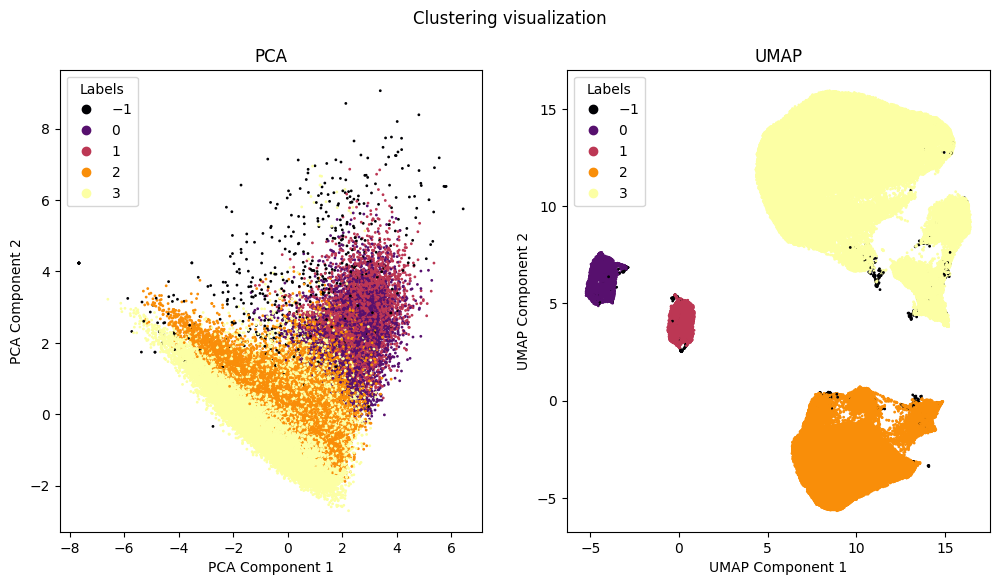

Cluster 3 size: 70979


,Track,Artist
0,I've Got a Feeling I'm Falling,Louis Armstrong
1,Rockin' Chair (Live) - 2001 Remastered,Louis Armstrong
2,Sweethearts on Parade,Louis Armstrong
3,"Love, You Funny Thing",Louis Armstrong
4,Do You Know What It Means to Miss New Orleans?...,Louis Armstrong
5,I'm Crazy 'Bout My Baby,Louis Armstrong
6,Summer Song,Louis Armstrong
7,(What Did I Do To Be So) Black And Blue,Louis Armstrong
8,Body and Soul,Louis Armstrong
9,I've Got The World On A String,Louis Armstrong


Top 10 genres in the cluster: ['rock', 'classic rock', 'adult standards', 'mellow gold', 'soft rock', 'album rock', 'folk rock', 'latin', 'country rock', 'soul']
Cluster 2 size: 30321


,Track,Artist
0,Start A Riot,BANNERS
1,Talk,Why Don't We
2,Evil Gal Blues - Live,Aretha Franklin
3,Wherever You Are - Live,Billie Holiday
4,All of Me,Billie Holiday
5,Anjunafamily (FYHYM2019),Above & Beyond
6,When Your Lover Has Gone,Louis Armstrong
7,Gone,Blake Rose
8,What They'll Say About Us,FINNEAS
9,Lazy River,Louis Armstrong


Top 10 genres in the cluster: ['rock', 'classic rock', 'adult standards', 'album rock', 'desi pop', 'mellow gold', 'soft rock', 'filmi', 'latin', 'sufi']
Cluster 0 size: 4466


,Track,Artist
0,Live Nigga Rap,Nas
1,Hey Daddy,Korn
2,Ruthless For Life,MC Ren
3,Children's Story,Slick Rick
4,Something Like That,N.W.A.
5,King Wizard,Kid Cudi
6,(We Are) The Roadcrew,Motörhead
7,Taki Taki,DJ Snake
8,If You See Her,LANY
9,in my head,Ariana Grande


Top 10 genres in the cluster: ['rap', 'hip hop', 'pop rap', 'gangster rap', 'southern hip hop', 'trap', 'pop', 'hardcore hip hop', 'dance pop', 'rock']
Cluster 1 size: 3829


,Track,Artist
0,Glass House,Machine Gun Kelly
1,Desaparecer,Mora
2,Mafioso,Beny Jr
3,Best You Had,Don Toliver
4,Freestyle 4,Kanye West
5,Love Hurts (feat. Travis Scott),Playboi Carti
6,Whatever U Like,Nicole Scherzinger
7,Greed,Godsmack
8,My Funeral,Dope
9,Hit the Hooker,Eazy-E


Top 10 genres in the cluster: ['rap', 'hip hop', 'pop rap', 'gangster rap', 'french hip hop', 'pop urbaine', 'trap', 'pop', 'southern hip hop', 'rap francais']


In [35]:
clusteing_hdbscan = HDBSCAN(
    min_samples=10, min_cluster_size=15, core_dist_n_jobs=-1, memory=memory
)
clusteing_hdbscan.fit(X)

hdbscan_analyzer.analyze_clustering(X, clusteing_hdbscan)

// skomentuj tutaj

Klastry wyglądają lepiej. Mają graficzny sens, ale nadal mamy klastry "rapowe" i "rockowe". CH-index sensownie wskazywał na jakość klasteryzacji. Testowałem trochę wartości `min_cluster_size` i wyszło mi, że po 15 wyniki zasadniczo się nie zmieniają.

## Zadanie dodatkowe (3 punkty)

Klasteryzacja hierarchiczna jest przydatnym narzędziem, dającym od razu znaczną ilość informacji co do klasteryzacji, ale ze względu na złożoność nadaje się tylko do mniejszych zbiorów danych. Takim zbiorem jest dobrze nam już znany [Ames housing](https://www.openintro.org/book/statdata/?data=ames).

1. Załaduj zbiór i dokonaj odpowiedniego preprocessingu. Zwizualizuj go z pomocą PCA oraz UMAP.

In [36]:
df_ames_housing = pd.read_csv("data/ames_data.csv")

In [37]:
# remove dots from names to match data_description.txt
df_ames_housing.columns = [col.replace(".", "") for col in df_ames_housing.columns]

df_ames_housing = df_ames_housing.drop(["Order", "PID"], axis="columns")
df_ames_housing = df_ames_housing.loc[
    ~df_ames_housing["Neighborhood"].isin(["GrnHill", "Landmrk"]), :
]

df_ames_housing = df_ames_housing.loc[df_ames_housing["GrLivArea"] <= 4000, :]

df_ames_housing.loc[:, "SalePrice"] = np.log1p(df_ames_housing.loc[:, "SalePrice"])

df_ames_housing = df_ames_housing.select_dtypes(exclude=["object"])

/tmp/ipykernel_227420/1377609497.py:11: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[12.27839796 11.56172515 12.05525557 ... 11.79056478 12.0435596
 12.14420256]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



In [38]:
print(f"Number of rows before dropping NaNs: {len(df_ames_housing)}")
df_ames_housing = df_ames_housing.dropna()
print(f"Number of rows after dropping NaNs: {len(df_ames_housing)}")

Number of rows before dropping NaNs: 2922
Number of rows after dropping NaNs: 2269


In [39]:
X_housing = StandardScaler().fit_transform(df_ames_housing)

/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



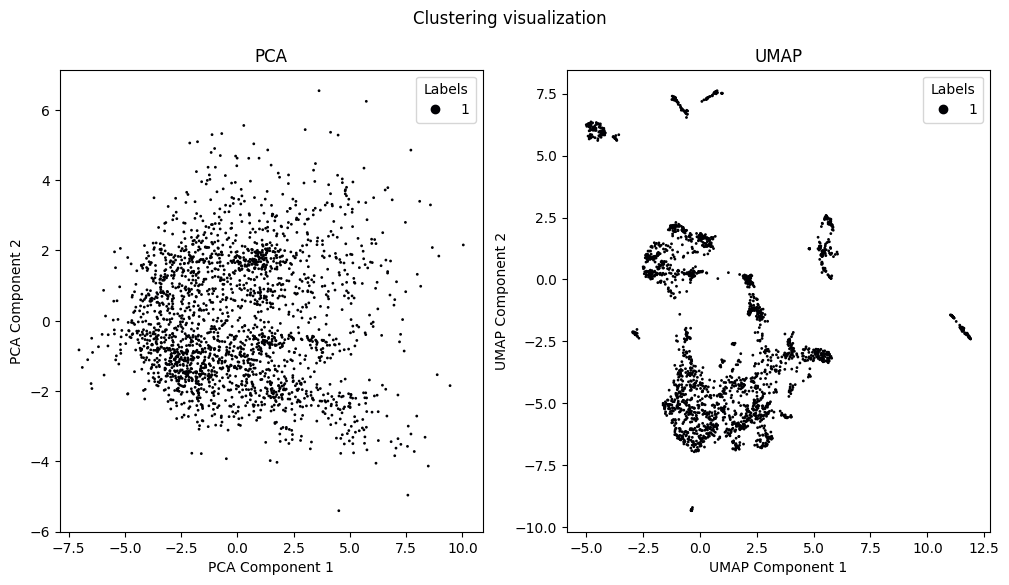

In [40]:
clustering_visualizer = ClusteringVisualizer(X_housing)
clustering_visualizer.visualize()

2. Zastosuj klasteryzację hierarchiczną do tego zbioru, wykorzystując metrykę euklidesową i Ward linkage.

In [41]:
from sklearn.cluster import AgglomerativeClustering

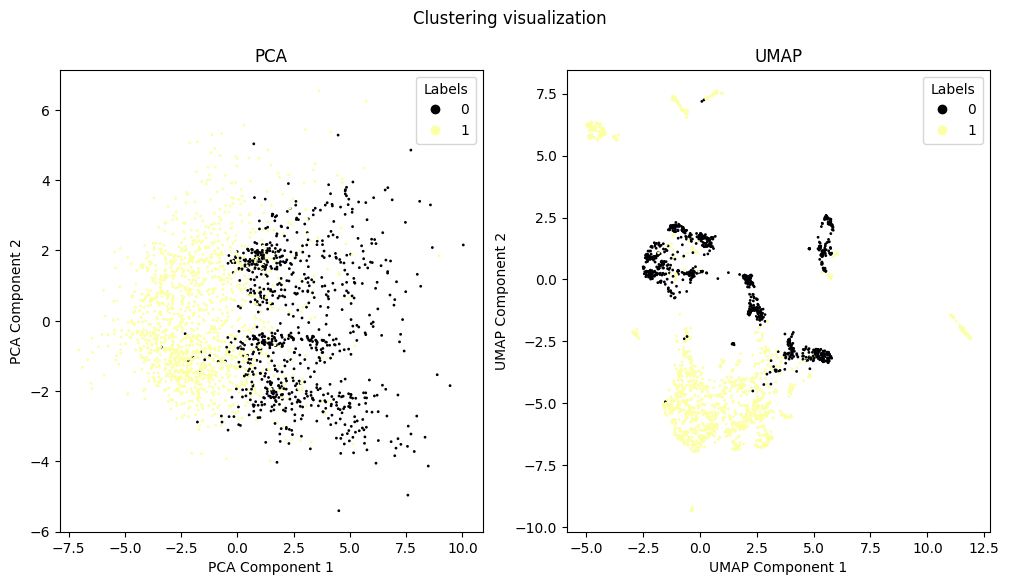

In [42]:
hierachical_clustering = AgglomerativeClustering(
    metric="euclidean", linkage="ward", distance_threshold=80, n_clusters=None
)
hierachical_clustering.fit(X_housing)
clustering_visualizer.visualize(hierachical_clustering.labels_)

3. Narysuj dendrogram dla wynikowej klasteryzacji. Czy widać jakąś strukturę klastrującą? Sprawdź kilka przykładowych próbek, które wydają się podobne - czy faktycznie te domy są podobne?

In [43]:
# from https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html
from scipy.cluster.hierarchy import dendrogram


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    fig, ax = plt.subplots(figsize=(60, 10))
    R = dendrogram(linkage_matrix, ax=ax, **kwargs)
    plt.title("Hierarchical Clustering Dendrogram")
    plt.xticks(rotation=90)
    plt.show()
    return R

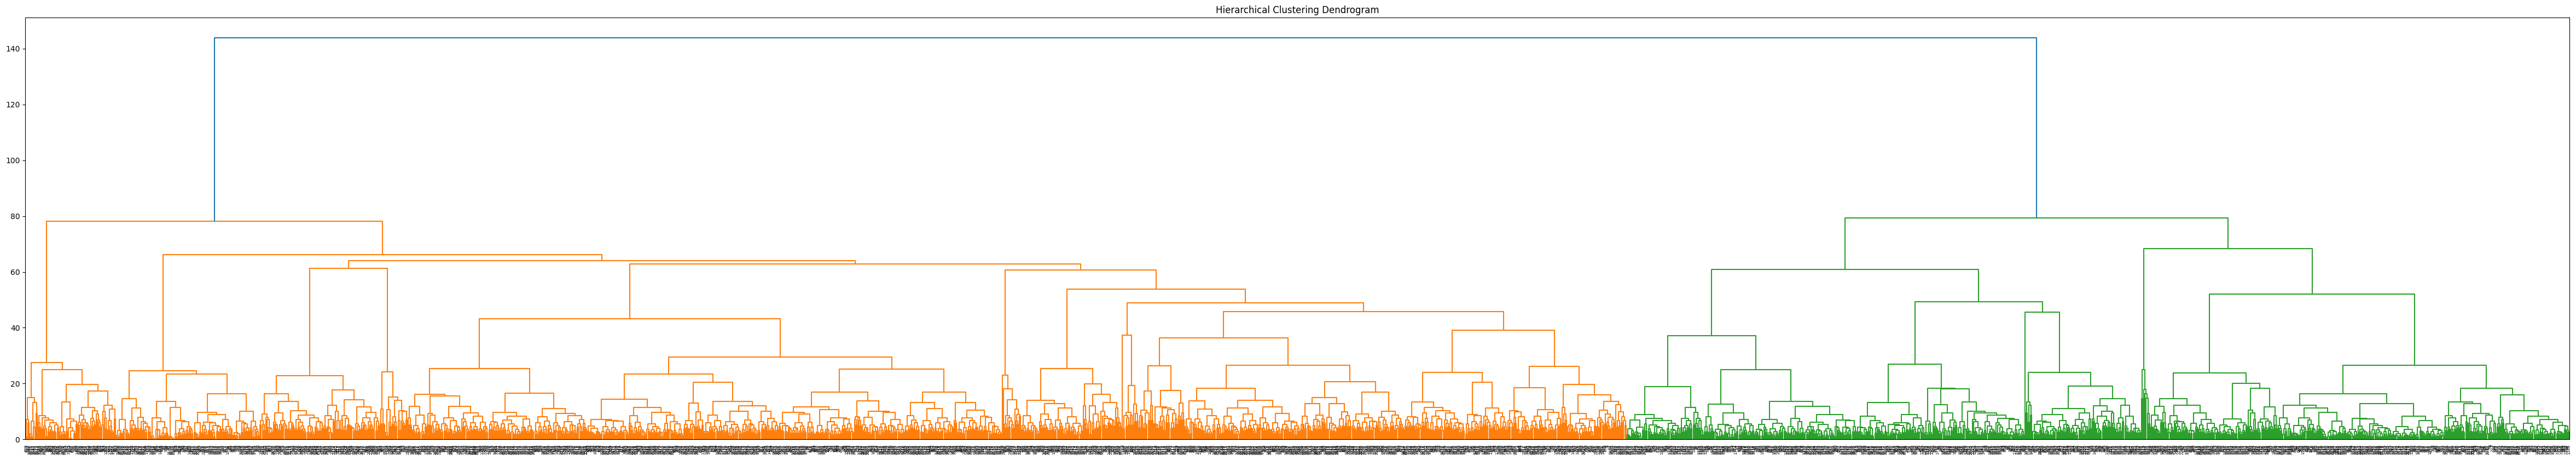

In [44]:
R = plot_dendrogram(
    hierachical_clustering,
)

4. Wybierz klasteryzację, która wydaje się najbardziej stabilna, tj. ma najdłuższe pionowe linie na dendrogramie. Sprawdź jej CH-index, oraz zwizualizuj ją za pomocą PCA oraz UMAP. Ile ma ona klastrów? Czy wydaje się ona sensowna? Wypisz przykładowe domy z klastrów. Czy faktycznie wskazują na zróżnicowanie klastrów?

In [45]:
ch_index = calinski_harabasz_score(X_housing, hierachical_clustering.labels_)
print(f"CH-index value: {ch_index:.2f}")
print(f"Number of clusters: {len(set(hierachical_clustering.labels_))}")

CH-index value: 318.94
Number of clusters: 2


In [46]:
cluster_label = 1
indices = np.where(hierachical_clustering.labels_ == cluster_label)[0]

df_ames_housing.iloc[indices]

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,...,210,62,0,0,0,0,0,5,2010,12.278398
1,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,140,0,0,0,120,0,0,6,2010,11.561725
2,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,393,36,0,0,0,0,12500,6,2010,12.055256
3,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,...,0,0,0,0,0,0,0,4,2010,12.404928
13,20,85.0,10176,7,5,1990,1990,0.0,637.0,0.0,...,192,0,0,0,0,0,0,2,2010,12.052344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,90,63.0,9297,5,5,1976,1976,0.0,1606.0,0.0,...,0,0,0,0,0,0,0,7,2006,12.144203
2923,20,80.0,17400,5,5,1977,1977,0.0,936.0,0.0,...,295,41,0,0,0,0,0,5,2006,11.982935
2924,20,160.0,20000,5,7,1960,1996,0.0,1224.0,0.0,...,474,0,0,0,0,0,0,9,2006,11.782960
2925,80,37.0,7937,6,6,1984,1984,0.0,819.0,0.0,...,120,0,0,0,0,0,0,3,2006,11.867104


In [47]:
cluster_label = 0
indices = np.where(hierachical_clustering.labels_ == cluster_label)[0]

df_ames_housing.iloc[indices]

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
4,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,212,34,0,0,0,0,0,3,2010,12.154258
5,60,78.0,9978,6,6,1998,1998,20.0,602.0,0.0,...,360,36,0,0,0,0,0,6,2010,12.183321
6,120,41.0,4920,8,5,2001,2001,0.0,616.0,0.0,...,0,0,170,0,0,0,0,4,2010,12.271397
7,120,43.0,5005,8,5,1992,1992,0.0,263.0,0.0,...,0,82,0,0,144,0,0,1,2010,12.162648
8,120,39.0,5389,8,5,1995,1996,0.0,1180.0,0.0,...,237,152,0,0,0,0,0,3,2010,12.373708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2901,20,88.0,11443,8,5,2005,2006,208.0,1460.0,0.0,...,326,66,0,0,0,0,0,3,2006,12.820991
2902,20,88.0,11577,9,5,2005,2006,382.0,1455.0,0.0,...,161,225,0,0,0,0,0,9,2006,12.793584
2905,120,32.0,4500,6,5,1998,1998,116.0,897.0,0.0,...,0,125,0,0,0,0,0,5,2006,12.007628
2906,120,32.0,4500,6,5,1998,1998,443.0,1201.0,0.0,...,0,199,0,0,0,0,0,3,2006,11.941462


Widać dwa wyraźne klastry. Bardziej zróżncowany jest `Cluster 0` - ma większe zakresy wartości dla poszczególnych cech (np. LotFrontage). Ogólnie domy w poszczególnych klastrach raczej są dla siebie podobne, ale nie jest to idealne klastrowannie, bo w obu klastrach są pojedyncze domy, które się bardzo różnią od reszty. Na ogół patrząc po `SalePrice`, `Cluster 0` ma też więcej drogich domów. W dendrogramie w obu klastrach są też dwa przypadki, które są oddzielone długimi liniami. W zielonym jest to podział blisko osi symetrii na zielonego poddrzewa na dendrogramie, a w pomarańczowym jest to pierwszy z lewej strony.

5. Porównaj tę klasteryzację z k-means (dokonaj tuningu liczby klastrów z pomocą CH-index) oraz HDBSCAN. Ile klastrów wybrały te metody? Czy na wizualizacji PCA i UMAP dają lepsze, czy gorsze wyniki od klasteryzacji hierarchicznej?

### K-means

In [48]:
N_CLUSTERS_SUITE = np.arange(2, 21)

In [49]:
callinski_harabasz_scores = np.zeros(len(N_CLUSTERS_SUITE))

best_clustering: KMeans
best_ch_score = -np.inf
best_ch_index = -1
best_k = -1

for i, n_clusters in enumerate(N_CLUSTERS_SUITE):
    clustering = KMeans(n_clusters=n_clusters, n_init="auto", random_state=0)
    clustering.fit(X_housing)

    current_ch_score = calinski_harabasz_score(X_housing, clustering.labels_)

    callinski_harabasz_scores[i] = current_ch_score

    if current_ch_score > best_ch_score:
        best_ch_score = current_ch_score
        best_clustering = clustering
        best_ch_index = i
        best_k = n_clusters


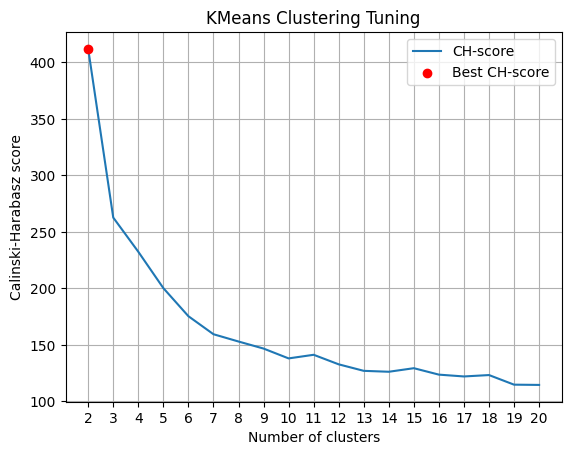

In [50]:
plt.plot(N_CLUSTERS_SUITE, callinski_harabasz_scores, label="CH-score")
plt.scatter(
    best_k,
    callinski_harabasz_scores[best_ch_index],
    color="red",
    zorder=5,
    label="Best CH-score",
)
plt.xlabel("Number of clusters")
plt.ylabel("Calinski-Harabasz score")
plt.title("KMeans Clustering Tuning")
plt.xticks(N_CLUSTERS_SUITE)
plt.grid()
plt.legend()
plt.show()

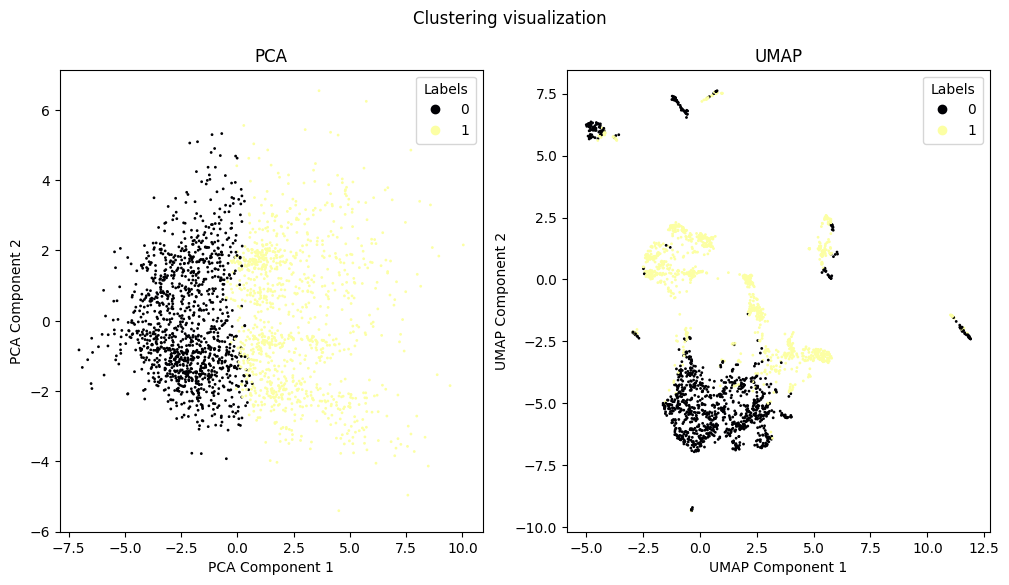

In [51]:
clustering_visualizer.visualize(best_clustering.labels_)

### HDBSCAN 1

In [52]:
from joblib import Memory

memory = Memory("./cache", verbose=0)

/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



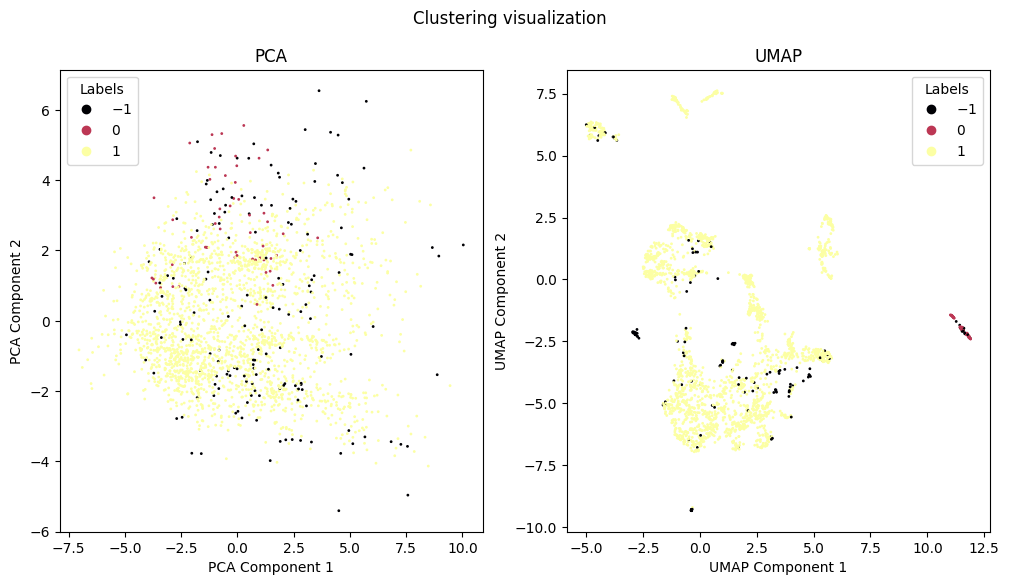

Number of clusters: 2
Percentage of noise points: 7.23%


In [53]:
clustering_hdbscan = HDBSCAN(
    min_samples=10, min_cluster_size=55, core_dist_n_jobs=-1, memory=memory
)
clustering_hdbscan.fit(X_housing)

labels = clustering_hdbscan.labels_

clustering_visualizer.visualize(labels)

noise_num = (labels == -1).sum()
noise_perc = noise_num / len(X_housing)
print(f"Number of clusters: {max(labels) + 1}")
print(f"Percentage of noise points: {100 * noise_perc:.2f}%")

### HDBSCAN 2

/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/aglited/agh/FML/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



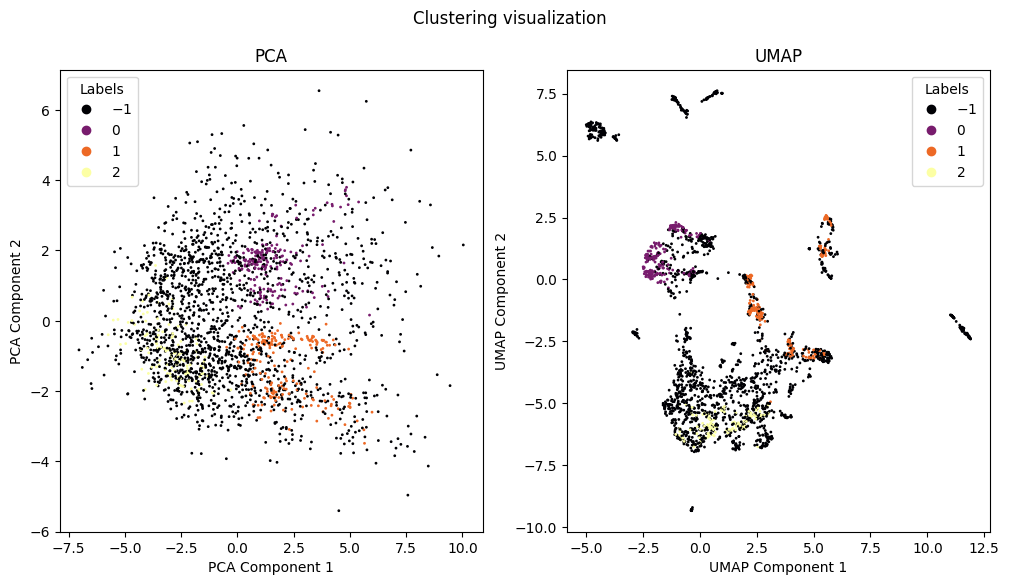

Number of clusters: 3
Percentage of noise points: 76.33%


In [54]:
clustering_hdbscan = HDBSCAN(
    min_samples=10, min_cluster_size=60, core_dist_n_jobs=-1, memory=memory
)
clustering_hdbscan.fit(X_housing)

labels = clustering_hdbscan.labels_

clustering_visualizer.visualize(labels)

noise_num = (labels == -1).sum()
noise_perc = noise_num / len(X_housing)
print(f"Number of clusters: {max(labels) + 1}")
print(f"Percentage of noise points: {100 * noise_perc:.2f}%")

`HDBSCAN` i `k-means` poradziły sobie gorzej niż klasteryzacja hierarchiczna. `HDBSCAN` przy tuningu znajdywał albo 2 klastry, które nie miały sensu albo 3 i MASĘ szumu (>70%!!!). `k-means` znajdywał 2 klastry, ale dane były gorzej odseparowane.